In [ ]:
import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import torch
import torch.nn as nn
from sklearn.feature_extraction.text import TfidfVectorizer, TfidfTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans,HDBSCAN
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.model_selection import train_test_split, KFold
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/driver')

Drive already mounted at /content/driver; to attempt to forcibly remount, call drive.mount("/content/driver", force_remount=True).


In [ ]:
f = pd.read_csv('driver/MyDrive/medium.csv')

In [ ]:
title = f['Title']
article = f['Text']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(article,title,)

In [ ]:
# tfidf = TfidfVectorizer(min_df=5, max_df=0.95)
tfidf = TfidfVectorizer(min_df=3)
tfidf.fit(X_train.values.tolist()+
          y_train.values.tolist())
article_tnf_tr = tfidf.transform(X_train)
article_tnf_ts = tfidf.transform(X_test)
title_tnf_tr = tfidf.transform(y_train)
title_tnf_ts = tfidf.transform(y_test)

In [ ]:
def unsuper_val(article_tnf_tr=article_tnf_tr, title_tnf_tr=title_tnf_tr,
                article_tnf_ts=article_tnf_ts, title_tnf_ts=title_tnf_ts, ):
  x_tr = np.argmax(article_tnf_tr@title_tnf_tr.T,axis=1)
  y_tr = np.argmax(article_tnf_tr@title_tnf_tr.T,axis=0)
  x_ts = np.argmax(article_tnf_ts@title_tnf_ts.T,axis=1)
  y_ts = np.argmax(article_tnf_ts@title_tnf_ts.T,axis=0)
  x_tr_val = np.max(article_tnf_tr@title_tnf_tr.T,axis=1)
  y_tr_val = np.max(article_tnf_tr@title_tnf_tr.T,axis=0)
  x_ts_val = np.max(article_tnf_ts@title_tnf_ts.T,axis=1)
  y_ts_val = np.max(article_tnf_ts@title_tnf_ts.T,axis=0)
  print(np.array([
  (np.array(x_tr.T)==np.arange(len(x_tr))).sum()/len(x_tr),\
  (np.array(y_tr)==np.arange(len(x_tr))).sum()/len(x_tr),\
  (np.array(x_ts.T)==np.arange(len(x_ts))).sum()/len(x_ts),\
  (np.array(y_ts)==np.arange(len(x_ts))).sum()/len(x_ts),\
  ((np.array(x_tr.T)==np.arange(len(x_tr)))+(np.array(y_tr)==np.arange(len(x_tr)))).sum()/len(x_tr),\
  ((np.array(x_ts.T)==np.arange(len(x_ts)))+(np.array(y_ts)==np.arange(len(x_ts)))).sum()/len(x_ts)
]))
  return x_tr, y_tr, x_ts, y_ts, x_tr_val, y_tr_val, x_ts_val, y_ts_val

In [ ]:
x_tr, y_tr, x_ts, y_ts, x_tr_val, y_tr_val, x_ts_val, y_ts_val = unsuper_val()

[0.43528284 0.54362416 0.56609195 0.62356322 0.60977948 0.69827586]


In [ ]:
sum([j in i for i,j in zip(torch.topk(
torch.tensor((article_tnf_tr@title_tnf_tr.T).todense()), 3).indices,
torch.arange(article_tnf_tr.shape[0]))])/article_tnf_tr.shape[0],\
sum([j in i for i,j in zip(torch.topk(
torch.tensor((article_tnf_ts@title_tnf_ts.T).todense()), 3).indices,
torch.arange(article_tnf_ts.shape[0]))])/article_tnf_ts.shape[0]

(0.5877277085330777, 0.6982758620689655)

### distribution ispection of matmul title vec with article vec for finding best threshold for output to get best matching vecs pairs or pairs of vec with triplets of vecs

(array([  2.,  14.,  66., 161., 157., 112.,  58.,  12.,   4.,   3.]),
 array([0.0781235 , 0.13015601, 0.18218851, 0.23422101, 0.28625352,
        0.33828602, 0.39031852, 0.44235103, 0.49438353, 0.54641603,
        0.59844854]),
 <BarContainer object of 10 artists>)

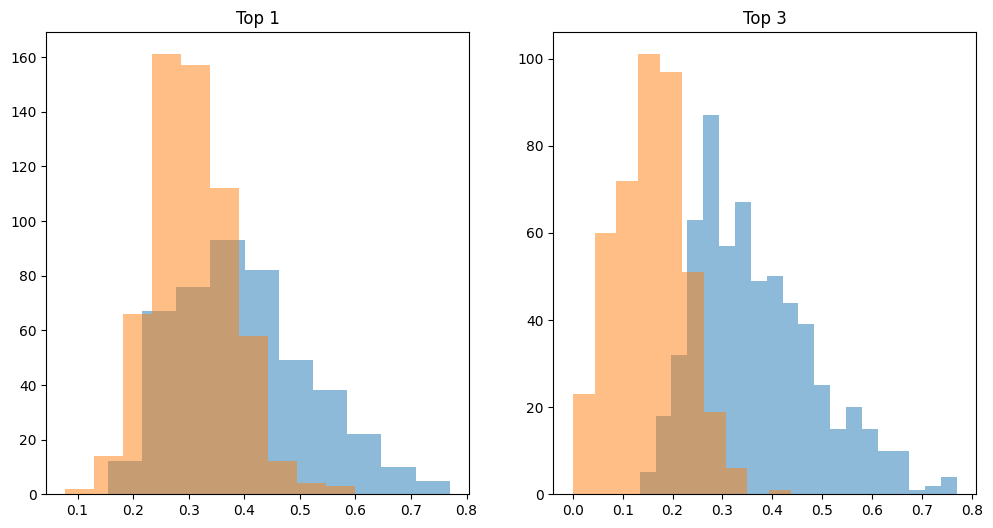

In [ ]:
fg, ax = plt.subplots(1,2,figsize=(12,6))
x_tr_tk = torch.topk(
torch.tensor((article_tnf_tr@title_tnf_tr.T).todense()), 3)
ax[1].hist(torch.concat([
x_tr_tk.values.T[0][
x_tr_tk.indices.T[0]==np.arange(len(x_tr_tk.values))],
x_tr_tk.values.T[1][
x_tr_tk.indices.T[1]==np.arange(len(x_tr_tk.values))],
x_tr_tk.values.T[2][
x_tr_tk.indices.T[2]==np.arange(len(x_tr_tk.values))]]),
alpha=.5, bins=20)
msk = ~np.array([j in i for i,j in zip(torch.topk(
torch.tensor((article_tnf_tr@title_tnf_tr.T).todense()), 3).indices,
torch.arange(article_tnf_tr.shape[0]))])
ax[1].hist(
np.array(
    (article_tnf_tr@title_tnf_tr.T).todense())[
np.arange(len(msk))[msk],
np.arange(len(msk))[msk]], alpha=0.5
)
ax[0].set_title('Top 1')
ax[1].set_title('Top 3')
ax[0].hist(np.array(
x_tr_val.todense()
).T[0][
np.array(x_tr).T[0]==np.arange(len(x_tr))
],alpha=.5)
ax[0].hist(np.array(
x_tr_val.todense()
).T[0][
np.array(x_tr).T[0]!=np.arange(len(x_tr))
],alpha=.5)

In [ ]:
from sklearn.decomposition import TruncatedSVD

In [ ]:
tsvd = TruncatedSVD(5)
svd_a_tnf_tr = tsvd.fit_transform(article_tnf_tr)
aa=[]
for i in range(5,45):
  km = KMeans(i)
  km.fit(svd_a_tnf_tr)
  aa += [km]

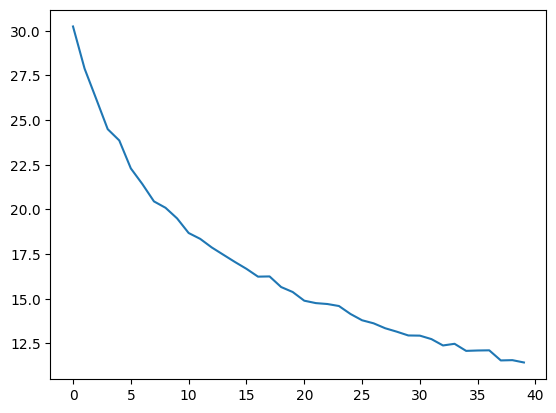

In [ ]:
plt.plot([i.inertia_ for i in aa])

In [ ]:
vocab = tfidf.get_feature_names_out()

In [ ]:
x = torch.topk(torch.tensor(aa[12].cluster_centers_@aa[12].cluster_centers_.T), 4).indices

In [ ]:
lbls = torch.nn.functional.one_hot(torch.tensor(aa[12].labels_, dtype=torch.long))

In [ ]:
# one hot keys of labels
ohk = torch.nn.functional.one_hot(torch.tensor(aa[7].labels_, dtype=torch.long))

In [ ]:
def minmaxargs10(a):
  mn = torch.argsort(a)[:10].reshape(1,-1)
  mx = torch.argsort(a)[-10:].reshape(1,-1)
  return torch.concat([mn, mx], axis=0)

In [ ]:
# clusteres centers from sparse vectors
cls_cnt_spr = (article_tnf_tr.T@ohk/ohk.sum(axis=0)).T
cls_cnt_spr
msk = (1-torch.nn.functional.one_hot(torch.arange(max(aa[7].labels_)+1, dtype=torch.long))).type(torch.bool)

[tensor([[ 9899,  5889,  6435,  3946,  9142,  1806,  7259,  6105,  4573, 10058],
         [ 9143,  6298,  5013,  1425,   705,  8031,  8030,  9252,  8026,  2448]]),
 tensor([[ 2448, 10134, 10137,  8026,   578,  5028,  6012,  7259,  5545,  9252],
         [ 5261,  7821,  3946,  8660,   555,  6105,  4573,  5013,  6298,  9142]]),
 tensor([[ 9142,  2448, 10134,  5889,  5013, 10137,  9252,  9983,  9899,  8026],
         [ 7453,  1337,  9164,   705,  6107,  2533,  6109,  1990,   578,  5297]]),
 tensor([[9142, 5889, 9899, 9252, 5028, 4573, 3946, 1480,  578, 9141],
         [2407, 5124, 6537, 1206, 8179, 8599, 1425, 7259, 8026, 2448]]),
 tensor([[ 9142,  6298,  2448,  5013,   705,  9141,  5889,  9899,  4646,  9252],
         [ 5353,  3298,  4830,  5114,  4615,  1806,  4828, 10137,  7259, 10134]]),
 tensor([[10134,  2448,  5889, 10137,  3946,  1806,  7259,  2458,  4615,  9706],
         [ 5028,  4646,  4871,  4489,  9141,  9252,   705,  9142,   578,  6298]]),
 tensor([[ 2448,  8026,  5297,   578

In [ ]:
torch.argmax(torch.randint(0,10,[100,100]),axis=0)

tensor([ 0, 10,  3,  1,  2,  5,  4,  2,  9,  7, 27,  7,  5,  5,  0, 14,  5,  4,
         9, 43, 12,  1,  8, 13, 21,  4,  1,  3,  0,  9,  1,  1,  6,  3, 14,  8,
         1,  4,  9, 34,  3, 19,  7,  6,  3,  1,  7,  2, 15, 15,  5,  1, 16, 11,
         1,  5,  8,  3,  6,  8,  0,  3,  7,  5, 18,  9,  3, 15,  0,  1, 17, 20,
        12, 10, 21,  4,  7, 10,  6,  4, 17, 17, 14,  7, 16, 10,  0,  1, 11,  0,
        19, 18, 23,  1,  2,  7, 11,  0, 44,  3])

In [ ]:
def n_tfidf(x):
  ntfidf = TfidfVectorizer()
  y = ntfidf.fit_transform(x)
  print(y)
  ar = np.argsort(y, axis=0)
  mn = ar[:,:10]
  mx = ar[:,-10:]
  return [mn, mx]
  # return ar

In [ ]:
article_tnf_tr

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 309839 stored elements and shape (1043, 10156)>

In [ ]:
jnd_cls = np.array([' '.join(X_train[aa[7].labels_==i]) for i in range(12)])

# x,y =
#  ,axis=1)
[([jnd_cls[n],' '.join(jnd_cls[i])]) for n,i in enumerate(msk.numpy())]


Buffered data was truncated after reaching the output size limit.

In [ ]:
x,y = torch.concat([minmaxargs10(cls_cnt_spr[n]-cls_cnt_spr[i].sum(axis=0)/max(aa[7].labels_)) for n,i in enumerate(msk)],axis=1)


In [ ]:
[' '.join(i)for i in vocab[x].reshape(12,10)]

['we model our function the code python network image would',
 'data you your science ai it my python machine to',
 'the data you model is your to will we science',
 'the model we to it image function can ai that',
 'the of data is and that model we in to',
 'you data model your function code python dataset import value',
 'data science learning ai machine of scientist business they people',
 'you data to it and your model that we is',
 'you science your ai python my scientist people their scientists',
 'the you and to in of data ai science my',
 'the we data model function values value set between features',
 'the to of is and you that data in it']

In [ ]:
[' '.join(i)for i in vocab[y].reshape(12,10)]

['their of is business and scientists scientist to science data',
 'layer reward function state agent network image is of the',
 'recognition brain they and networks deep neural computer ai learning',
 'customer kaggle pandas big series sql business python science data',
 'libraries environment installed jupyter import code install your python you',
 'it in intelligence human that to and the ai of',
 'on text for function to this you file we the',
 'volume neighborhoods game bars pose clustering movies airbnb graph the',
 'accuracy features regression our of training is we model the',
 'points features classification models accuracy linear feature our we model',
 'me but that my if and it your to you',
 'self audio col auroc clusters stocks table spark import df']

In [ ]:
tt = torch.concat(
[torch.tensor(article_tnf_tr[aa[7].labels_==i].sum(axis=0)/(sum(aa[7].labels_==i))) for i in range(12)])

# [vocab[np.argsort((tt[~i]-tt[i].sum(axis=0)/11)>0)[:10]]
# for i in (1-torch.nn.functional.one_hot(torch.tensor(list(range(12))))).to(torch.bool)]

tensor([[0.0005, 0.0008, 0.0000,  ..., 0.0000, 0.0000, 0.0019],
        [0.0001, 0.0022, 0.0000,  ..., 0.0022, 0.0000, 0.0000],
        [0.0003, 0.0041, 0.0000,  ..., 0.0013, 0.0000, 0.0000],
        ...,
        [0.0019, 0.0034, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0053, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0024, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
       dtype=torch.float64)

In [ ]:
kfold = KFold(n_splits=5)
kfold.get_n_splits(article_tnf_tr)

for i,j in kfold.split(article_tnf_tr):
  hdbscan = HDBSCAN()
  hdbscan.fit(article_tnf_tr[i])
  print(set(hdbscan.labels_))
  print(sum(hdbscan.labels_))
  hdbscan = HDBSCAN()
  hdbscan.fit(article_tnf_tr[j])
  print(set(hdbscan.labels_))
  print(sum(hdbscan.labels_))

In [ ]:
aa[7].cluster_centers_

In [ ]:
msk1 = []
for i in range(1,article_tnf_tr.shape[0]):
  msk1 += [i]*i

a=list(range(article_tnf_tr.shape[0]))
msk2 = []
for i in range(1,article_tnf_tr.shape[0]):
  msk2 += a[:i]

In [ ]:
((article_tnf_tr@article_tnf_tr.T-np.eye(article_tnf_tr.shape[0]))>0.8).sum()

In [ ]:
(article_tnf_tr==0).sum(),\
(title_tnf_tr==0).sum(),\
(article_tnf_tr!=0).sum(),\
(title_tnf_tr!=0).sum()

In [ ]:
d1 = np.array((article_tnf_tr@article_tnf_tr.T).todense())
d2 = np.array((title_tnf_tr@title_tnf_tr.T).todense())
x1,y1 = linear_sum_assignment(1-(d1-np.eye((title_tnf_tr.shape[0]))))
x2,y2 = linear_sum_assignment(1-(d2-np.eye((title_tnf_tr.shape[0]))))

In [ ]:
(d1>d1[x1,y1][np.argsort(d1[x1,y1])][len(d1)//2]).sum()

In [ ]:
msk = np.argsort(tfidf.idf_)
tfidf.idf_[msk]

In [ ]:
x2,y2

In [ ]:
vocab = tfidf.vocabulary_
vocab = np.array(list(vocab.keys()))[
        np.argsort(list(vocab.values()))]

In [ ]:
set(vocab[np.array(tfidf.transform(X_train.values[[0]]).indices
)]).intersection(vocab[np.array(tfidf.transform(X_train.values[[639]]).indices)])